In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import oncapintada as onca

from mace.calculators import  MACECalculator
from ase.io import write, read
from ase.optimize import BFGS
from ase.filters import UnitCellFilter
from ase.build import bulk
from ase.phonons import Phonons

from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from mpltern.datasets import get_triangular_grid

import seaborn as sns
sns.set_style("ticks")

                                           
          ▄▖          ▘  ▗    ▌            
          ▌▌▛▌▛▘▀▌▄▖▛▌▌▛▌▜▘▀▌▛▌▀▌          
          ▙▌▌▌▙▖█▌  ▙▌▌▌▌▐▖█▌▙▌█▌          
                    ▌                      
                                           
    version: 26.4.16                 
    developed by: Leandro Seixas             
    homepage: https://github.com/seixasgroup/oncapintada
                                                  
------------------------------------------------------------
                                                  
System:
├── architecture: arm64
├── platform: Darwin
├── user: leseixas
├── hostname: safira
├── cwd: /Users/leseixas/Library/CloudStorage/Dropbox/Repositories/oncapintada/examples/notebooks/example03
└── PID: 39770
                                               
Python:
├── version: 3.13.2 | packaged by conda-forge | (main, Feb 14 2025, 08:14:38) [Clang 18.1.8 ]      
└── executable: /Users/leseixas/miniconda3/envs/mace/bin/pyt

# Enthalpy of mixing

In [2]:
# Supercell size for dilute alloy calculations
sc = [3,3,1]

In [3]:
# row is solute, column is solvent
energy_matrix = np.array(
    [ [ -199.105132, -196.134083, -200.262889 ],
      [ -198.585427, -195.794211, -199.774814],
      [ -199.267155, -196.271821, -200.385563] ]
)

print("Energy matrix (eV):")
print(energy_matrix)

Energy matrix (eV):
[[-199.105132 -196.134083 -200.262889]
 [-198.585427 -195.794211 -199.774814]
 [-199.267155 -196.271821 -200.385563]]


In [5]:
dilution = 1 / 9
print(f"Dilution: {dilution:.4f}")

mixing_model = onca.MultiComponentAlloy(energy_matrix=energy_matrix, dilution = dilution)

Mij = mixing_model.Mij()
print("Mij:")
print(Mij * 96.485) # in kJ/mol


Dilution: 0.1111
Mij:
[[-2.74226863e-12  2.70236260e+00 -1.89073078e+00]
 [ 1.46488244e+01 -2.74226863e-12  9.70627307e+00]
 [-1.90585748e+00  3.13964334e+00 -2.74226863e-12]]


In [6]:
energy_matrix.shape[0]

3

In [7]:
X = mixing_model.simplex_grid(N=3, resolution=5)
print("Simplex grid:")
print(X)

Simplex grid:
[[1.  0.  0. ]
 [0.8 0.2 0. ]
 [0.8 0.  0.2]
 [0.6 0.4 0. ]
 [0.6 0.2 0.2]
 [0.6 0.  0.4]
 [0.4 0.6 0. ]
 [0.4 0.4 0.2]
 [0.4 0.2 0.4]
 [0.4 0.  0.6]
 [0.2 0.8 0. ]
 [0.2 0.6 0.2]
 [0.2 0.4 0.4]
 [0.2 0.2 0.6]
 [0.2 0.  0.8]
 [0.  1.  0. ]
 [0.  0.8 0.2]
 [0.  0.6 0.4]
 [0.  0.4 0.6]
 [0.  0.2 0.8]
 [0.  0.  1. ]]


In [9]:
h_mix = mixing_model.enthalpy_of_mixing(X=X, normalized=True)
print("Shape of h_mix:", h_mix.shape)
print("h_mix values:", h_mix)

Shape of h_mix: (21,)
h_mix values: [ 0.          1.96153251 -0.30445429  2.36886644  1.42813967 -0.45595535
  1.79543411  1.66231758  1.15100262 -0.45522926  0.81466786  1.18050613
  1.4107781   1.08744021 -0.30300212  0.          0.71247777  1.38391606
  1.69911548  1.34287659  0.        ]


In [10]:
x1, x2, x3 = get_triangular_grid(11)
np.column_stack((x1.flatten(), x2.flatten(), x3.flatten()))

array([[1. , 0. , 0. ],
       [0.9, 0.1, 0. ],
       [0.9, 0. , 0.1],
       [0.8, 0.2, 0. ],
       [0.8, 0.1, 0.1],
       [0.8, 0. , 0.2],
       [0.7, 0.3, 0. ],
       [0.7, 0.2, 0.1],
       [0.7, 0.1, 0.2],
       [0.7, 0. , 0.3],
       [0.6, 0.4, 0. ],
       [0.6, 0.3, 0.1],
       [0.6, 0.2, 0.2],
       [0.6, 0.1, 0.3],
       [0.6, 0. , 0.4],
       [0.5, 0.5, 0. ],
       [0.5, 0.4, 0.1],
       [0.5, 0.3, 0.2],
       [0.5, 0.2, 0.3],
       [0.5, 0.1, 0.4],
       [0.5, 0. , 0.5],
       [0.4, 0.6, 0. ],
       [0.4, 0.5, 0.1],
       [0.4, 0.4, 0.2],
       [0.4, 0.3, 0.3],
       [0.4, 0.2, 0.4],
       [0.4, 0.1, 0.5],
       [0.4, 0. , 0.6],
       [0.3, 0.7, 0. ],
       [0.3, 0.6, 0.1],
       [0.3, 0.5, 0.2],
       [0.3, 0.4, 0.3],
       [0.3, 0.3, 0.4],
       [0.3, 0.2, 0.5],
       [0.3, 0.1, 0.6],
       [0.3, 0. , 0.7],
       [0.2, 0.8, 0. ],
       [0.2, 0.7, 0.1],
       [0.2, 0.6, 0.2],
       [0.2, 0.5, 0.3],
       [0.2, 0.4, 0.4],
       [0.2, 0.3

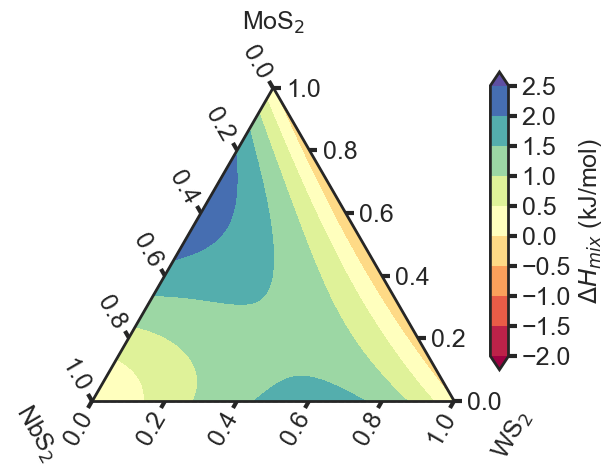

In [15]:
fig = plt.figure(figsize=(10.8, 4.8))
ax = plt.subplot(projection="ternary")

x1, x2, x3 = get_triangular_grid(101) # MoS2, NbS2, WS2
h_mix_grid = mixing_model.enthalpy_of_mixing(X=np.column_stack((x1.flatten(), x2.flatten(), x3.flatten())), normalized=True)

levels = np.arange(-2,3, 0.5)
cs = ax.tricontourf(x1, x2, x3, h_mix_grid, cmap="Spectral", levels=levels, extend='both') # levels=levels,  vmin=vmin, vmax=vmax

ax.set_tlabel(r"MoS$_2$", fontsize=18)
ax.set_llabel(r"NbS$_2$", fontsize=18)
ax.set_rlabel(r"WS$_2$", fontsize=18)

ax.taxis.set_major_locator(MultipleLocator(0.20))
ax.laxis.set_major_locator(MultipleLocator(0.20))
ax.raxis.set_major_locator(MultipleLocator(0.20))

ax.grid(axis='l', which='major', linestyle='--', linewidth=1, color='black')
ax.grid(axis='r', which='major', linestyle='--', linewidth=1, color='black')
ax.grid(axis='t', which='major', linestyle='--', linewidth=1, color='black')

cax = ax.inset_axes([1.10, 0.1, 0.05, 0.95], transform=ax.transAxes)
colorbar = fig.colorbar(cs, cax=cax)
colorbar.set_label(r'$\Delta H_{mix}$ (kJ/mol)', rotation=90, fontsize=18)

plt.tick_params(axis='both', which='major', labelsize=18, width=3, length=6)
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

colorbar.set_ticks(levels)
cax.tick_params(axis='both', which='major', labelsize=18, width=3, length=6)
for spine in cax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
fig.savefig("ternary_plot.png", dpi=500)
plt.show()

In [16]:
path1 = mixing_model.line_profile(npoints=101, y1=np.array([0, 1, 0]), y2=np.array([1/2, 0, 1/2]))

In [20]:
# Line profiles

npoints = 101
x = np.linspace(0, 1, npoints)

y1 = np.array([0, 1, 0])
y2 = np.array([1/2, 0, 1/2])
path1 = mixing_model.line_profile(npoints=npoints, y1=y1, y2=y2)

p1 = np.array([0, 1, 0])
p2 = np.array([0,0,1])
path2 = mixing_model.line_profile(npoints=npoints, y1=p1, y2=p2)

q1 = np.array([0,1,0])
q2 = np.array([1, 0,0])
path3 = mixing_model.line_profile(npoints=npoints, y1=q1, y2=q2)

h_mix_NbMoW = mixing_model.enthalpy_of_mixing(X=path1, normalized=True)

h_mix_NbMo = mixing_model.enthalpy_of_mixing(X=path2, normalized=True)

h_mix_NbW = mixing_model.enthalpy_of_mixing(X=path3, normalized=True)


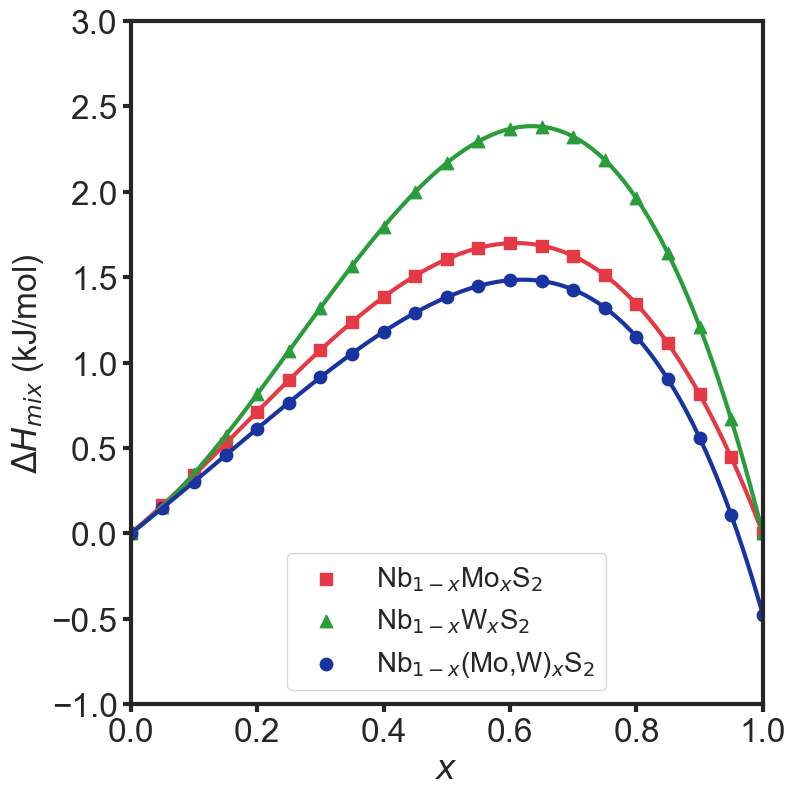

In [21]:
fig, ax = plt.subplots(1,1, figsize=(8,8))
lw = 3
fontsize = 24
markersize = 80
color1="#1834A0"
color2="#E63946"
color3="#2A9D3B"

ax.plot(x, h_mix_NbMo, color=color2, linewidth=lw)
ax.scatter(x[::5], h_mix_NbMo[::5], color=color2, s=markersize, marker="s", label="Nb$_{1-x}$Mo$_x$S$_2$") # square markers

ax.plot(x, h_mix_NbW, color=color3, linewidth=lw)
ax.scatter(x[::5], h_mix_NbW[::5], color=color3, s=markersize, marker="^", label="Nb$_{1-x}$W$_x$S$_2$") # triangle markers

ax.plot(x, h_mix_NbMoW, color=color1, linewidth=lw)
ax.scatter(x[::5], h_mix_NbMoW[::5], color=color1, s=markersize, marker="o", label="Nb$_{1-x}$(Mo,W)$_x$S$_2$") # circle markers

ax.set_xlabel("$x$", fontsize=fontsize)
ax.set_ylabel(r"$\Delta H_{mix}$ (kJ/mol)", fontsize=fontsize)
ax.set_xlim(0, 1)
ax.set_ylim(-1,3)

# Setting axes properties
ax.tick_params(axis='both', direction='out', which='major', labelsize=fontsize, width=lw, length=6, zorder=5)
for spine in ax.spines.values():
    spine.set_linewidth(lw)

plt.legend(fontsize=20, loc="lower center")
plt.tight_layout()
fig.savefig("Nb_Mo_W_S2_mixing_enthalpy.png", dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()
